In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))  # adds /home/patroklos/delphi.ai to the path

from delphi.grad import TruncatedUnknownVarianceMSE

import torch as ch
import matplotlib.pyplot as plt
%matplotlib notebook
import numpy as np
from sklearn.linear_model import LinearRegression

ch.set_printoptions(precision=4, sci_mode=False)

In [86]:
import numpy as np
from scipy.linalg import solve_sylvester
from scipy.stats import chi2, norm

def project_to_psd(M, eps=1e-8):
    M = (M + M.T)/2
    eigvals, eigvecs = ch.linalg.eigh(M)
    eigvals_clipped = ch.clamp(eigvals, min=eps)
    return eigvecs @ ch.diag(eigvals_clipped) @ eigvecs.T

def compute_Gamma_from_grads(grads):
    # grads: (n, k+1)
    n = grads.shape[0]
    return (grads.T @ grads) / n   # (k+1, k+1)

def build_R(w_hat, sigma2_hat):
    k = w_hat.size(0)
    sigma4 = sigma2_hat**2
    top_left = (1.0 / sigma2_hat) * ch.eye(k)            # (k,k)
    top_right = (-w_hat / sigma4).reshape(k, 1)          # (k,1)
    bottom_left = ch.zeros((1, k))                       # (1,k)
    bottom_right = -1.0 / sigma4
    R = ch.cat([ch.cat([top_left, top_right], dim=1), 
                ch.cat([bottom_left, bottom_right], dim=1)], dim=0)
    return R  # (k+1, k+1)

def solve_for_Sigma(H_hat, Gamma, zeta):
    # Solve (H_hat - zeta/2 I) Sigma + Sigma (H_hat - zeta/2 I) = Gamma
    A = H_hat - 0.5*zeta * np.eye(H_hat.shape[0])
    # use solve_sylvester: A X + X A = Gamma
    Sigma = project_to_psd(ch.from_numpy(solve_sylvester(A, A, Gamma)))
    return Sigma

def asymptotic_covariance_M(H_hat, grads, w_hat, sigma2_hat, zeta):
    Gamma = compute_Gamma_from_grads(grads)
    Sigma = solve_for_Sigma(H_hat, Gamma, zeta).float()
    R = build_R(w_hat, sigma2_hat)
    M = R.T @ Sigma @ R            # R^T Sigma R
    S = project_to_psd((1.0 / zeta) * M)           # S = 1/zeta * R^T Sigma R
    return {'Gamma': Gamma, 'Sigma': Sigma, 'R': R, 'M': M, 'S': S}

def joint_confidence_ellipsoid_center_radius(M, zeta, n, alpha=0.05):
    # Return threshold t so that (theta - theta_hat)^T M (theta - theta_hat) <= t
    # paper writes t = q_alpha / (zeta * n)
    q_alpha = chi2.ppf(1 - alpha, df=M.shape[0])   # q_{alpha}
    threshold = q_alpha / (zeta * n)
    return threshold

def marginal_CI_from_S(S, n, alpha=0.05):
    # S is  (k+1,k+1) (S = 1/zeta * R^T Sigma R)
    z = norm.ppf(1 - alpha/2)
    print(f'z: {z}')
    print(f'S: {S}')
    se = np.sqrt(np.diag(S) / n)
    print(f'se: {se}')
    lower = - z * se   # centered at 0; user should add to hat theta
    print(f'lower: {lower}')
    upper =   z * se
    print(f'upper: {upper}')
    return np.vstack([lower, upper]).T  # (k+1, 2)  ; +/- offsets

# Example usage:
# outputs = asymptotic_covariance_M(H_hat, grads, w_hat, sigma2_hat, zeta)
# threshold = joint_confidence_ellipsoid_center_radius(outputs['M'], zeta, n, alpha=0.05)
# marg_offsets = marginal_CI_from_S(outputs['S'], n, alpha=0.05)
# Then joint region: (theta - theta_hat)^T outputs['M'] (theta - theta_hat) <= threshold
# and marginal CI for theta_j is [theta_hat_j + marg_offsets[j,0], theta_hat_j + marg_offsets[j,1]]


In [79]:
import time 

def generate_data(phi, num_samples, W, NOISE_VAR, W0=0, D=1, verbose=False):
    current_time_seed = int(time.time() * 1000)
    ch.manual_seed(current_time_seed)
    a, b = 0, 1
    
    x_trunc, y_trunc = ch.Tensor([]), ch.Tensor([])
    X, Y = ch.Tensor([]), ch.Tensor([])
    sampled = 0
    while x_trunc.size(0) < num_samples:
        x = (b - a) * ch.rand(num_samples, D) + a
                
        y = x @ W + W0 + (NOISE_VAR ** .5) * ch.randn(num_samples, 1)
        
        X = ch.cat([X, x])
        Y = ch.cat([Y, y])
        
        trunc_indices = phi(y).flatten().nonzero().flatten()
        y_trunc = ch.cat([y_trunc, y[trunc_indices]]) 
        x_trunc = ch.cat([x_trunc, x[trunc_indices]])
        sampled += num_samples

    alpha = x_trunc.size(0) / sampled
    if verbose: print(f'alpha: {alpha:.3f}')
    
    return x_trunc[:num_samples], y_trunc[:num_samples], alpha, X, Y

W = ch.ones(2, 1)
NOISE_VAR = 1.0
def phi(x): 
    return x > 0

x_trunc, y_trunc, alpha, X, Y = generate_data(phi, 1000, W, NOISE_VAR, D=2, verbose=True)

alpha: 0.824


In [4]:
def cross_cov(A, B, rowvar=True):
    """
    Compute cross-covariance between two data matrices A and B.

    Args:
        A: Tensor of shape (d1, n) if rowvar=True, else (n, d1)
        B: Tensor of shape (d2, n) if rowvar=True, else (n, d2)
        rowvar: If True, rows are variables and columns are observations.

    Returns:
        Covariance matrix of shape (d1, d2)
    """
    if A.dim() != 2 or B.dim() != 2:
        raise ValueError("A and B must be 2D tensors")
    if rowvar:
        if A.size(1) != B.size(1):
            raise ValueError("A and B must have same number of observations (columns)")
        A_ = A - A.mean(dim=1, keepdim=True)
        B_ = B - B.mean(dim=1, keepdim=True)
        fact = 1.0 / (A.size(1) - 1)
        return fact * A_.matmul(B_.t())
    else:
        if A.size(0) != B.size(0):
            raise ValueError("A and B must have same number of observations (rows)")
        A_ = A - A.mean(dim=0, keepdim=True)
        B_ = B - B.mean(dim=0, keepdim=True)
        fact = 1.0 / (A.size(0) - 1)
        return fact * A_.t().matmul(B_)

def hessian(phi, X, pred, variance, num_samples=1000, eps=1e-5): 
    stacked = pred.repeat(num_samples, 1, 1)
    z_i = pred + (variance ** .5) * ch.randn_like(pred)
    
    mask_i = phi(z_i).float()

    mean_z_i = (mask_i * z_i).sum() / (mask_i.sum() + eps)
    var_z_i  = ((mask_i * (z_i - mean_z_i)**2).sum() / (mask_i.sum() + eps))
    mean_z2half_i = (mask_i * 0.5*z_i**2).sum() / (mask_i.sum() + eps)
    cov_z2_z_i = (mask_i * ((0.5*z_i**2 - mean_z2half_i)*(z_i - mean_z_i))).sum() / (mask_i.sum() + eps)
    var_z2_i = (mask_i * (0.5*z_i**2 - mean_z2half_i)**2).sum() / (mask_i.sum() + eps)

    
    xx_T = ch.bmm(X.unsqueeze(2), X.unsqueeze(1))

    upper_left = (var_z_i * xx_T).mean(0)
    upper_right = (-cov_z2_z_i * X).mean(0, keepdim=True).T
    bottom_left = (-cov_z2_z_i * X).mean(0)
    bottom_right = var_z2_i.mean(0, keepdim=True).resize(1,)
    
    H = torch.cat([
        torch.cat([upper_left, upper_right], dim=1),
        torch.cat([bottom_left, bottom_right])[None,...]
    ], dim=0)
    
    return H

In [82]:
def calculate_grads(X, Y, lambda_, phi, W):   
#     w_grads = ch.empty(X.size(0), W.size(0), 1)
    w_grads = ch.Tensor([])
    lambda_grads = ch.Tensor([])
#     lambda_grads = ch.empty(X.size(0), 1, 1)

    for i in range(len(Y)): 
        # Move the prediction calculation inside the loop
        pred_i = X[i] @ W

        lambda_.requires_grad = True
        W.requires_grad = True
#         import pdb; pdb.set_trace()

        if lambda_.grad is not None: 
            lambda_.grad.zero_()

        # Ensure W's gradient is reset before the backward pass
        if W.grad is not None:
            W.grad.zero_()

        loss = TruncatedUnknownVarianceMSE.apply(pred_i, Y[i], lambda_, phi).sum()
        loss.backward()

        # Now W.grad contains the gradient from this iteration
        w_grads = ch.cat([w_grads, W.grad.T])
        lambda_grads = ch.cat([lambda_grads, lambda_.grad])

    return ch.cat([w_grads, lambda_grads], dim=1)

grads = calculate_grads(X, Y, ch.ones(1, 1), phi, W)

In [87]:
pred = (X@W)

import torch


H_hat = hessian(phi, X, pred, 1.0)
grads = calculate_grads(X, Y, ch.ones(1, 1), phi, W)
zeta = 10

outputs = asymptotic_covariance_M(H_hat.detach(), grads, W.detach(), ch.ones(1, 1), zeta)
threshold = joint_confidence_ellipsoid_center_radius(outputs["M"], zeta, X.size(0), alpha=.5)
marginal_CI_from_S(outputs["S"], X.size(0))


z: 1.959963984540054
S: tensor([[     0.0000,      0.0000,     -0.0000],
        [     0.0000,      0.0000,      0.0000],
        [    -0.0000,      0.0000,      0.0000]])
se: [2.2360680e-06 2.2360678e-06 2.2360680e-06]
lower: [-4.38261272e-06 -4.38261227e-06 -4.38261272e-06]
upper: [4.38261272e-06 4.38261227e-06 4.38261272e-06]


/tmp/ipykernel_131845/3685979365.py:29: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  A = H_hat - 0.5*zeta * np.eye(H_hat.shape[0])


array([[-4.38261272e-06,  4.38261272e-06],
       [-4.38261227e-06,  4.38261227e-06],
       [-4.38261272e-06,  4.38261272e-06]])

In [88]:
# Symmetry check
asym = (H_hat - H_hat.T).abs().max()
print(f"Asymmetry: {asym.item():.3e}")

# Eigenvalues
eigvals = ch.linalg.eigvalsh(H_hat)
print("Eigenvalues:", eigvals)

Asymmetry: 0.000e+00
Eigenvalues: tensor([0.0630, 0.0819, 2.4204], grad_fn=<LinalgEighBackward0>)


<IPython.core.display.Javascript object>


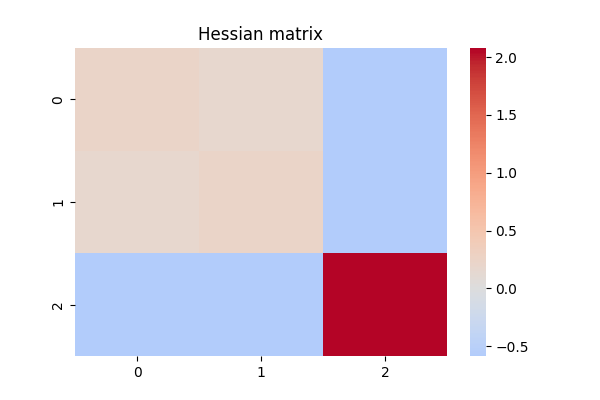


Hessian shape: torch.Size([3, 3])
Hessian symmetry check: 0.000e+00
Hessian eigenvalues: [0.06297 0.08194 2.42037]


In [89]:
import matplotlib.pyplot as plt
import seaborn as sns

def check_matrix(name, M):
    fig, ax = plt.subplots(1, 1, figsize=(6, 4))

    M_np = M.detach().cpu().numpy()
    print(f"\n{name} shape: {M.shape}")
    print(f"{name} symmetry check: {(M - M.T).abs().max().item():.3e}")
    print(f"{name} eigenvalues: {np.round(np.linalg.eigvalsh(M_np), 5)}")
    sns.heatmap(M_np, cmap="coolwarm", center=0, ax=ax)
    plt.title(f"{name} matrix")
    plt.show()
    
    
check_matrix('Hessian', H_hat)


<IPython.core.display.Javascript object>


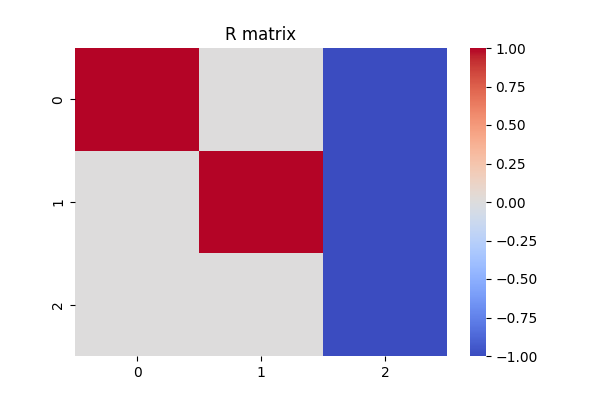


R shape: torch.Size([3, 3])
R symmetry check: 1.000e+00
R eigenvalues: [-1.  1.  1.]


<IPython.core.display.Javascript object>


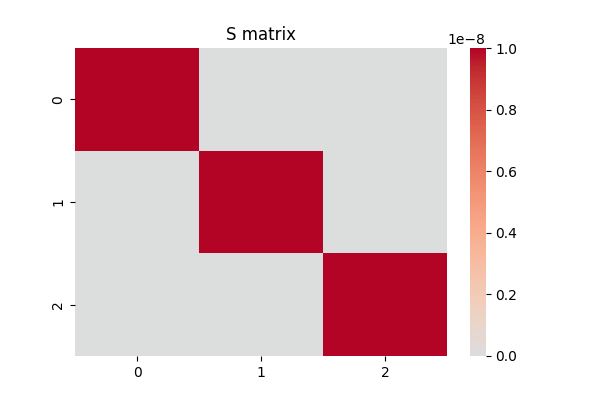


S shape: torch.Size([3, 3])
S symmetry check: 4.916e-16
S eigenvalues: [0. 0. 0.]


<IPython.core.display.Javascript object>


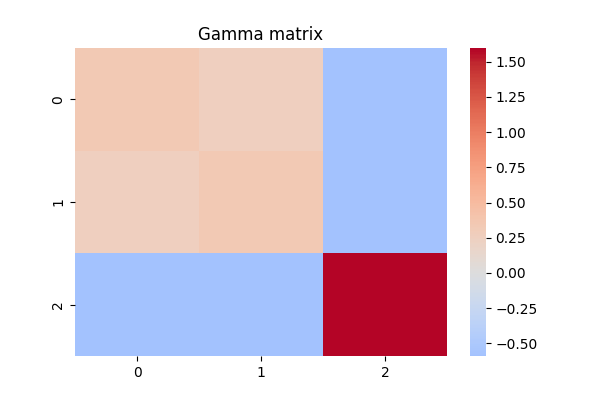


Gamma shape: torch.Size([3, 3])
Gamma symmetry check: 0.000e+00
Gamma eigenvalues: [0.09396 0.12108 2.06982]


<IPython.core.display.Javascript object>


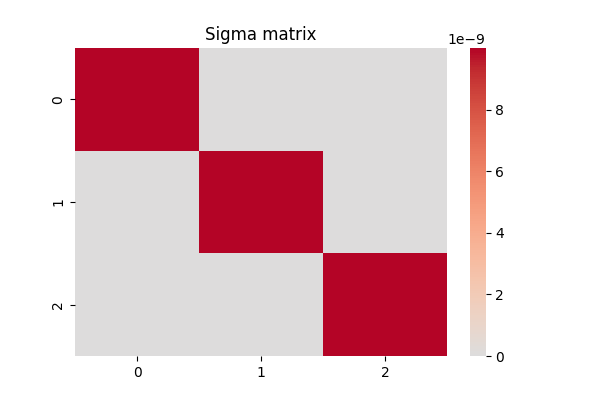


Sigma shape: torch.Size([3, 3])
Sigma symmetry check: 1.104e-24
Sigma eigenvalues: [0. 0. 0.]


<IPython.core.display.Javascript object>


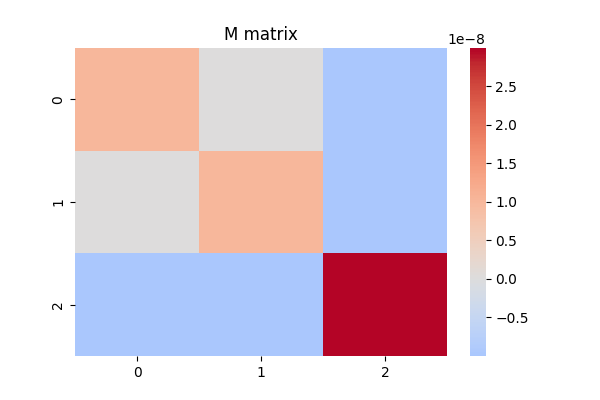


M shape: torch.Size([3, 3])
M symmetry check: 1.104e-24
M eigenvalues: [0. 0. 0.]


In [90]:
check_matrix('R', outputs['R'])
check_matrix('S', outputs['S'])
check_matrix('Gamma', outputs['Gamma'])
check_matrix('Sigma', outputs['Sigma'])
check_matrix('M', outputs['M'])

In [91]:
from matplotlib.patches import Ellipse

def plot_ellipse(cov, mean, ax=None, color='r', alpha=0.3):
    if ax is None:
        ax = plt.gca()
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    theta = np.degrees(np.arctan2(*vecs[:,0][::-1]))
    width, height = 2 * np.sqrt(vals)
    ell = Ellipse(xy=mean, width=width, height=height, angle=theta, color=color, alpha=alpha)
    ax.add_patch(ell)
    return ax

<IPython.core.display.Javascript object>


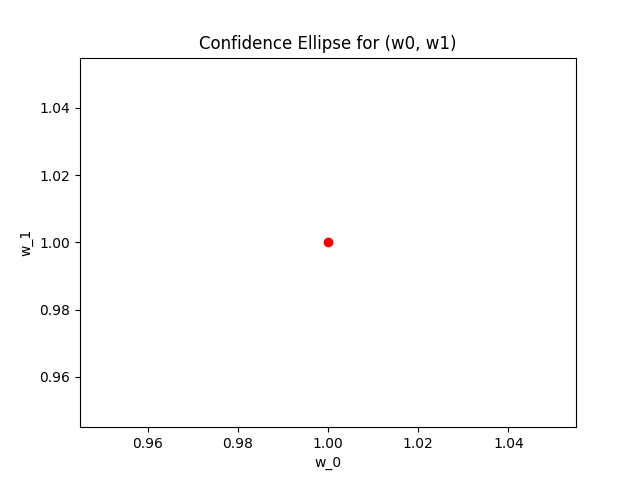

/tmp/ipykernel_131845/1609592600.py:10: RuntimeWarning: invalid value encountered in sqrt
  width, height = 2 * np.sqrt(vals)


In [95]:
import matplotlib.pyplot as plt

# Pick indices of parameters
i, j = 0, 1  # first two weights
cov_2d = S[[i,j]][:,[i,j]].detach().cpu().numpy()
mean_2d = ch.cat([W, ch.ones(1, 1)])[[i,j]].detach().cpu().numpy()

fig, ax = plt.subplots()
ax.scatter(mean_2d[0], mean_2d[1], color='red')  # plot center
plot_ellipse(cov_2d, mean_2d, ax=ax, color='blue', alpha=0.3)
ax.set_xlabel(f'w_{i}')
ax.set_ylabel(f'w_{j}')
ax.set_title('Confidence Ellipse for (w0, w1)')
plt.show()


In [ ]:
import matplotlib.pyplot as plt

# Pick indices of parameters
i, j = 0, 1  # first two weights
cov_2d = S[[i,j]][:,[i,j]].detach().cpu().numpy()
mean_2d = ch.cat([hat_w, hat_sigma2[None]])[[i,j]].detach().cpu().numpy()

fig, ax = plt.subplots()
ax.scatter(mean_2d[0], mean_2d[1], color='red')  # plot center
plot_ellipse(cov_2d, mean_2d, ax=ax, color='blue', alpha=0.3)
ax.set_xlabel(f'w_{i}')
ax.set_ylabel(f'w_{j}')
ax.set_title('Confidence Ellipse for (w0, w1)')
plt.show()


In [91]:
W.requires = False 
W.detach()
W.grad

tensor([[0.1200],
        [0.1145]])

In [92]:
W.requires_grad = True
pred = (X@W)
ch.autograd.grad(loss, inputs=pred, retain_graph=True)

RuntimeError: One of the differentiated Tensors appears to not have been used in the graph. Set allow_unused=True if this is the desired behavior.

In [ ]:
# outputs = asymptotic_covariance_M(H_hat, grads, w_hat, sigma2_hat, zeta)
# threshold = joint_confidence_ellipsoid_center_radius(outputs['M'], zeta, n, alpha=0.05)
# marg_offsets = marginal_CI_from_S(outputs['S'], n, alpha=0.05)